In [1]:
import numpy as np # linear algebra
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv('../input/train.csv')
x_pred= pd.read_csv('../input/test.csv')


In [3]:
df.head()

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


In [4]:
df.shape

(913000, 4)

In [5]:
df['date'] = pd.to_datetime(df['date'])

In [6]:
df_sample = df[(df['store'] == 1) & (df['item'] == 1)].copy()
df_sample = df_sample[['date', 'sales']].set_index('date')
df_sample.head()

,sales
date,
2013-01-01,13
2013-01-02,11
2013-01-03,14
2013-01-04,13
2013-01-05,10


In [7]:
df_sample.shape

(1826, 1)

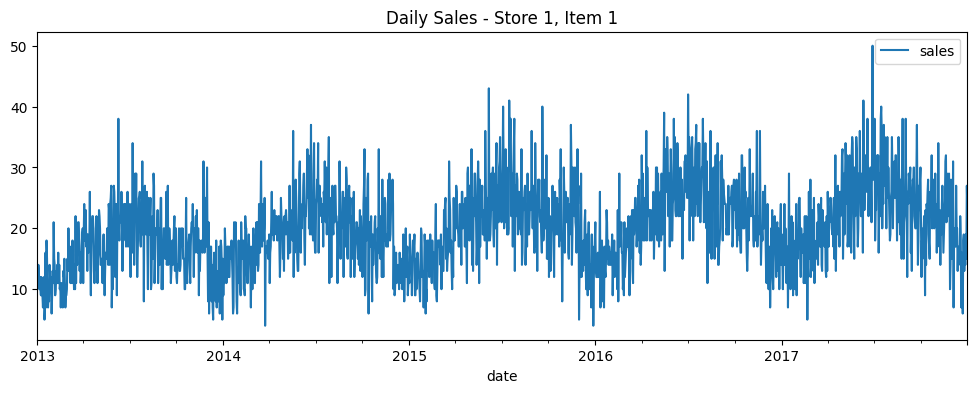

In [8]:
import matplotlib.pyplot as plt
df_sample.plot(figsize=(12,4), title='Daily Sales - Store 1, Item 1')
plt.show()

/tmp/ipykernel_16/3549325009.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = df_sample.resample('M').sum()


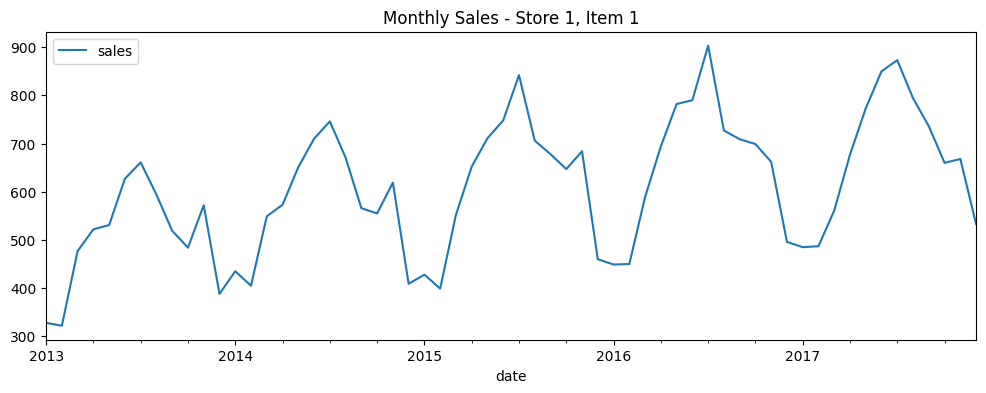

In [9]:
monthly = df_sample.resample('M').sum()
monthly.plot(figsize=(12,4), title='Monthly Sales - Store 1, Item 1')
plt.show()

In [10]:
train = monthly[:-12]
test = monthly[-12:]

In [11]:
!pip install --upgrade statsmodels

In [12]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

model = ExponentialSmoothing(train['sales'], trend='add', seasonal='add', seasonal_periods=12)
fit = model.fit()

forecast = fit.forecast(12)

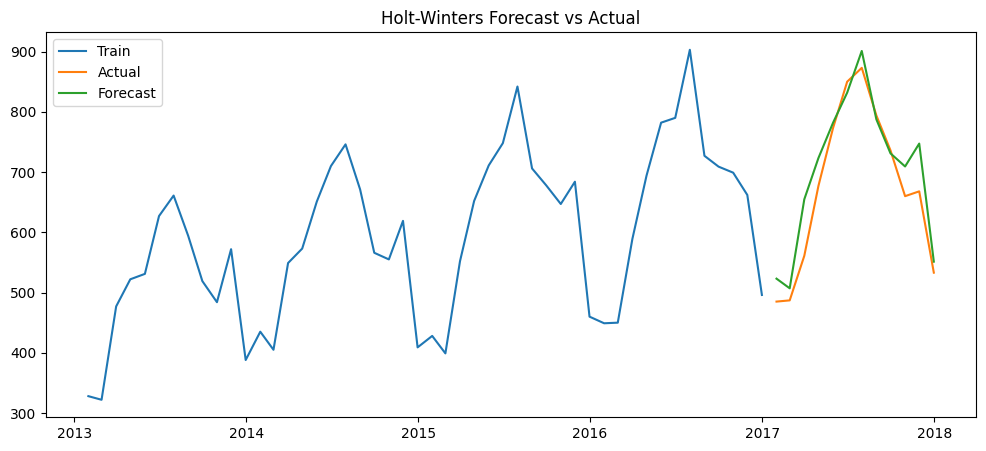

In [13]:
plt.figure(figsize=(12,5))
plt.plot(train.index, train['sales'], label='Train')
plt.plot(test.index, test['sales'], label='Actual')
plt.plot(test.index, forecast, label='Forecast')
plt.legend()
plt.title('Holt-Winters Forecast vs Actual')
plt.show()

In [14]:
from sklearn.metrics import mean_absolute_percentage_error

mape = mean_absolute_percentage_error(test['sales'], forecast)
print(f'MAPE: {mape*100:.2f}%')

MAPE: 5.52%


# Sales Forecasting — Store 1, Item 1

**Goal:** Forecast next 12 months of sales using historical daily sales data (2013-2017).

**Method:** 
- Aggregated daily sales to monthly totals
- Applied Holt-Winters Exponential Smoothing (additive trend + additive seasonality, 12-month cycle)
- Held out last 12 months as test set to validate accuracy

**Result:** 5.52% MAPE (Mean Absolute Percentage Error) — forecast closely tracked actual sales trend and seasonal pattern.

**Tools:** Python, pandas, statsmodels, matplotlib